In [9]:
import numpy as np, math, time
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray
import cv2

def plot_image(image, title=''):
    plt.imshow(image)
    plt.axis('off')
    plt.title(title, size=20)

def zeropadding(img):
    h, w = img.shape[:2]
    m = 1 << int(np.ceil(np.log2(h)))         # 2의 자승 계산
    n = 1 << int(np.ceil(np.log2(w)))
    dst = np.zeros((m, n), img.dtype)        # 2의 자승 크기 영상 생성
    dst[0:h, 0:w] = img[:]                         # 자승 영상에 원본 영상 복사
    # cv2.imshow('zeropadding',dst)
    return dst

def butterfly(pair, L, N, dir):
    for k in range(L):                                       # 버터플라이 수행
        Geven, Godd = pair[k], pair[k + L]
        pair[k]     = Geven + Godd * exp(dir * k / N)       # 짝수부
        pair[k + L] = Geven - Godd * exp(dir * k / N)       # 홀수부

def pairing(g, N, dir, start=0, stride=1):
    if N == 1: return [g[start]]
    L = N // 2
    sd = stride * 2
    part1 = pairing(g, L, dir, start, sd)
    part2 = pairing(g, L, dir, start + stride, sd)
    pair = part1 + part2                                     # 결과 병합
    butterfly(pair, L, N, dir)
    return pair

def exp(knN):
    th = -2 * math.pi * knN
    return complex(math.cos(th), math.sin(th))

def fft(g):
    return pairing(g, len(g), 1)

def ifft(g):
    fft = pairing(g, len(g), -1)
    return [v / len(g) for v in fft]

def fft2(image):
    pad_img = zeropadding(image)  # 영삽입
    tmp = [fft(row) for row in pad_img]
    dst = [fft(row) for row in np.transpose(tmp)]
    return np.transpose(dst)                        # 전치 환원 후 반환

def ifft2(image):
    tmp = [ifft(row) for row in image]
    dst = [ifft(row) for row in np.transpose(tmp)]
    return np.transpose(dst)                        # 전치 환원 후 반환

def calc_spectrum(complex):
    if complex.ndim == 2: dst = abs(complex)                   # sqrt(re^2 + im^2) 계산해줌
    else: dst = cv2.magnitude(complex[:,:,0], complex[:,:,1])
    dst = 20*np.log(dst+1)
    return cv2.convertScaleAbs(dst)

def fftshift(img):
    dst = np.zeros(img.shape, img.dtype)
    h, w = dst.shape[:2]
    cy, cx = h // 2, w // 2                     # 나누기 하며 소수점 절삭
    dst[h-cy:, w-cx:] = np.copy(img[0:cy , 0:cx ])      # 1사분면 -> 3사분면
    dst[0:cy , 0:cx ] = np.copy(img[h-cy:, w-cx:])      # 3사분면 -> 1사분면
    dst[0:cy , w-cx:] = np.copy(img[h-cy:, 0:cx ])      # 2사분면 -> 4사분면
    dst[h-cy:, 0:cx ] = np.copy(img[0:cy , w-cx:])      # 4사분면 -> 2사분면
    return dst

def FFT(image, mode = 2):
    if mode == 1: dft = fft2(image)
    elif mode==2: dft = np.fft.fft2(image)
    elif mode==3: dft = cv2.dft(np.float32(image), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft = fftshift(dft)                              # 셔플링
    spectrum = calc_spectrum(dft)               # 주파수 스펙트럼 영상
    return dft, spectrum

def IFFT(dft, size, mode=2):
    dft = fftshift(dft)                                 # 역 셔플링
    if mode == 1: img = ifft2(dft).real
    if mode == 2: img = np.fft.ifft2(dft).real
    if mode ==3:  img = cv2.idft(dft, flags= cv2.DFT_SCALE)[:,:,0]

    img = img[0:size[0], 0:size[1]]                 # 영삽입 부분 제거
    return cv2.convertScaleAbs(img)

def ck_time(mode = 0):
    global stime
    if (mode ==0 ):
       stime = time.perf_counter()
    elif (mode==1):
       etime = time.perf_counter()
       print("수행시간 = %.5f sec" % (etime - stime))   #초 단위 경과 시간

수행시간 = 0.17553 sec


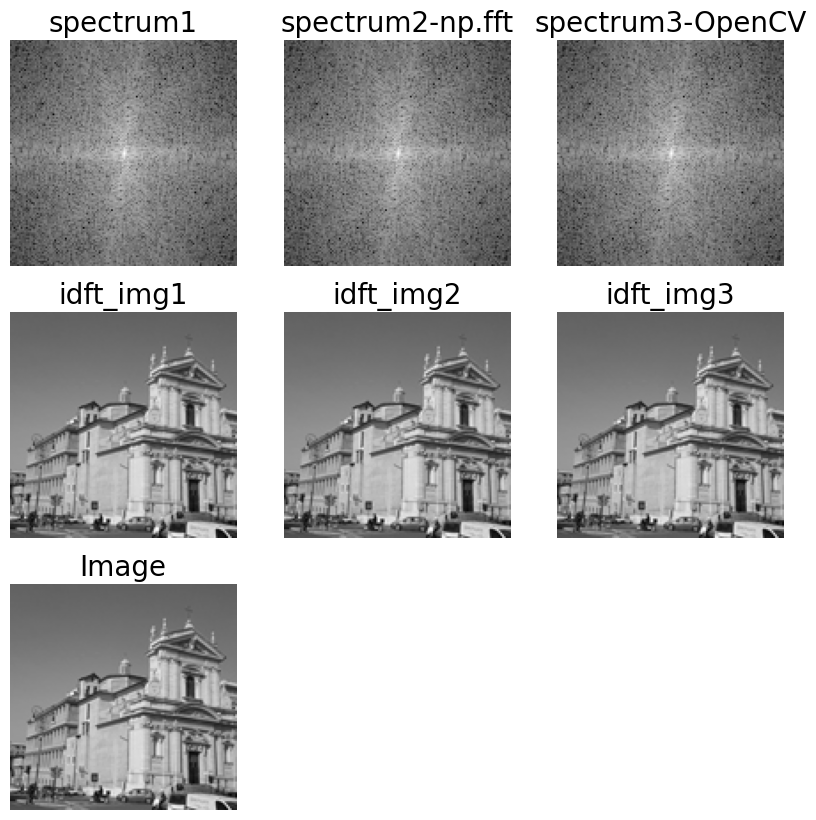

In [13]:
image = cv2.imread('build_128.jpg', cv2.IMREAD_GRAYSCALE)
#image = cv2.imread('build_300.jpg', cv2.IMREAD_GRAYSCALE)

dft1 = fft2(image)                                # 2차원 DFT 수행
dft2 = np.fft.fft2(image)                                # 2차원 DFT 수행
dft3 = cv2.dft(np.float32(image), flags = cv2.DFT_COMPLEX_OUTPUT)

spectrum1 = calc_spectrum(fftshift(dft1))           # 셔플링후 주파수 스펙트럼 영상 생성
spectrum2 = calc_spectrum(fftshift(dft2))           # 주파수 스펙트럼 영상
spectrum3 = calc_spectrum(fftshift(dft3))           # 주파수 스펙트럼 영상

ck_time(0)
idft1 = ifft2(dft1).real                          # 2차원 IDFT 수행
ck_time(1)
idft2 = np.fft.ifft2(dft2).real                          # 2차원 IDFT 수행
idft3 = cv2.idft(dft3, flags=cv2.DFT_SCALE)[:,:,0]

plt.figure(figsize=(10,10))
plt.gray()
plt.subplot(331), plot_image(spectrum1, 'spectrum1')
plt.subplot(332), plot_image(spectrum2, 'spectrum2-np.fft')
plt.subplot(333), plot_image(spectrum3, 'spectrum3-OpenCV')

plt.subplot(334), plot_image(cv2.convertScaleAbs(idft1), 'idft_img1')
plt.subplot(335), plot_image(cv2.convertScaleAbs(idft2), 'idft_img2')
plt.subplot(336), plot_image(cv2.convertScaleAbs(idft3), 'idft_img3')

plt.subplot(337), plot_image(image, 'Image')
plt.show()